In [1]:
# =========================================
# 📚 IMPORT ALL REQUIRED LIBRARIES (FINAL CLEAN)
# =========================================

# Data
import pandas as pd
import numpy as np

# Text processing
import re

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Visualization
import matplotlib.pyplot as plt

# Utils
from scipy.sparse import hstack
import joblib
import random
import os

In [2]:
#LOAD DATASET

In [3]:
# =========================================
# 📂 LOAD DATASET
# =========================================

data = pd.read_csv(
    "../datasets/tigrigna_translated_news_dataset_final_updated.csv",
    encoding="utf-8-sig"
)

# Clean column names
data.columns = data.columns.str.strip().str.lower()

print("Columns:", data.columns.tolist())
print(data.head())


# =========================================
# 🚨 BASIC VALIDATION
# =========================================

assert 'label' in data.columns
assert 'text' in data.columns or 'tigrigna_translated_text' in data.columns


# =========================================
# 🔀 SHUFFLE DATA (GOOD PRACTICE)
# =========================================

data = data.sample(frac=1, random_state=42).reset_index(drop=True)


# =========================================
# 🚨 LEAKAGE CHECK (CRITICAL)
# =========================================

print("\n🔍 SOURCE vs LABEL DISTRIBUTION:")
print(data.groupby('source')['label'].value_counts(normalize=True))


# If you see something like:
# source A → 100% REAL
# source B → 100% FAKE
# → THIS IS THE REASON FOR 1.0 ACCURACY

Columns: ['tigrigna_translated_text', 'label', 'source', 'credibility_score']
                            tigrigna_translated_text  label  \
0  ላዕለዋይ ቤት ፍርዲ ማሳቹሰትስ ብዛዕባ ማእሰርቲ ስደተኛታት ዝሃቦ ውሳነ ...      1   
1  ኣመሪካ ብሰንኪ እቲ ኣብ ልዕሊ ዘይመንግስታውያን ትካላት ዝተወሰነ ቀይዲ፡...      1   
2  ረክስ ቲለርሰን ካብ ስልጣኖም ከምዘይለቁን ምስ ትራምፕ ጽቡቕ ርክብ ከምዘ...      1   
3  ኣባላት ኮንግረስ ኣመሪካ ኣብ ልዕሊ ሩስያ ሓድሽ እገዳ ንምንባር ተሰማሚዖ...      1   
4  ዶናልድ ትራምፕ ንገዛኢ ክፍለ-ሃገር ካንሳስ ሳም ብራውንባክ ኣምባሳደር ኣ...      1   

                  source  credibility_score  
0                    CNN               0.87  
1                Reuters               0.98  
2  Associated Press (AP)               0.98  
3           PBS NewsHour               0.96  
4                    NPR               0.95  

🔍 SOURCE vs LABEL DISTRIBUTION:
source                  label
ABC News                1        1.0
Al Jazeera English      1        1.0
American Patriot Daily  0        1.0
American Thinker        0        1.0
Associated Press (AP)   1        1.0
                   

In [4]:
# =========================================
# 🚨 PREVENT METADATA LEAKAGE
# =========================================

# Shuffle dataset
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# Check distribution
print(data.groupby('source')['label'].value_counts())

source                  label
ABC News                1        48
Al Jazeera English      1        54
American Patriot Daily  0        51
American Thinker        0        50
Associated Press (AP)   1        48
                                 ..
Washington Post         1        48
WorldTruthTV            0        50
YourNewsWire            0        50
Zero Hedge              0        50
the Blaze               0         1
Name: count, Length: 61, dtype: int64


In [5]:
# =========================================
# 🧹 STANDARDIZE COLUMN NAMES
# =========================================

data.columns = data.columns.str.replace('\ufeff', '', regex=True).str.strip().str.lower()

data.rename(columns={
    'tigrigna_translated_text': 'text'
}, inplace=True)

print(data.columns)
print(data[['text']].head())

Index(['text', 'label', 'source', 'credibility_score'], dtype='object')
                                                text
0  ዩናይትድ ስቴትስ ኤምባሲ ኣብ ሊባኖስ ሎሚ ዕለት ተዘጊቡ ኣሎ፣ ድሕሪ እቶ...
1  ሓድሽ ስትራተጂ ሃገራዊ ድሕነት ኣመሪካን ጽልዋ ሩስያን\nምምሕዳር ፕረዚደ...
2  ዋሽንግተን (ሳንዲ ሃፋከር/ጌቲ ኢሜጅስ) - ፕረዚደንት ዶናልድ ትራምፕ ነ...
3  ለንደን፦ ብሪጣንያ ነቲ ፕሬዚዳንት ትራምፕ ኣብ ኣፍጋኒስታን ዝወሰዱዎ ሓድ...
4  መራሕቲ ደሞክራት ጆን ኮንየርስ ካብ ስልጣኑ ንክለቅቅ ጸዊዖም\nናንሲ ፔሎ...


In [6]:
# =========================================
# 🧹 STANDARDIZE COLUMN NAMES
# =========================================

data.columns = data.columns.str.replace('\ufeff', '', regex=True).str.strip().str.lower()

data.rename(columns={
    'tigrigna_translated_text': 'text'
}, inplace=True)


# =========================================
# 🧹 TEXT CLEANING
# =========================================

def clean_text(text):
    text = str(text)

    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    text = re.sub(r'[።፣፤፥፦፧፨]', '', text)
    text = re.sub(r'[^\w\s\u1200-\u137F]', '', text)
    text = re.sub(r'[0-9]', '', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


# =========================================
# 🏷 LABEL CLEANING
# =========================================

data = data.dropna(subset=['text', 'label'])

if data['label'].dtype == 'object':
    label_encoder = LabelEncoder()
    data['label'] = label_encoder.fit_transform(data['label'])

data['label'] = data['label'].astype(int)


# =========================================
# 🔤 TIGRIGNA NORMALIZATION
# =========================================

def normalize_tigrigna(text):
    text = str(text).strip()

    replacements = {
        "አ": "ኣ", "ዐ": "ኣ",
        "ሐ": "ሀ", "ኀ": "ሀ", "ሓ": "ሀ",
        "ሸ": "ሠ", "ጸ": "ፀ",
        "ኸ": "ካ", "ዘ": "ዠ",
        "ደ": "ዳ", "ገ": "ጋ",
        "በ": "ባ", "ፐ": "ፓ",
        "፡": " "
    }

    for k, v in replacements.items():
        text = text.replace(k, v)

    return text


# APPLY
data['clean_text'] = data['text'].apply(clean_text)
data['clean_text'] = data['clean_text'].apply(normalize_tigrigna)

print(data[['text', 'clean_text']].head())

                                                text  \
0  ዩናይትድ ስቴትስ ኤምባሲ ኣብ ሊባኖስ ሎሚ ዕለት ተዘጊቡ ኣሎ፣ ድሕሪ እቶ...   
1  ሓድሽ ስትራተጂ ሃገራዊ ድሕነት ኣመሪካን ጽልዋ ሩስያን\nምምሕዳር ፕረዚደ...   
2  ዋሽንግተን (ሳንዲ ሃፋከር/ጌቲ ኢሜጅስ) - ፕረዚደንት ዶናልድ ትራምፕ ነ...   
3  ለንደን፦ ብሪጣንያ ነቲ ፕሬዚዳንት ትራምፕ ኣብ ኣፍጋኒስታን ዝወሰዱዎ ሓድ...   
4  መራሕቲ ደሞክራት ጆን ኮንየርስ ካብ ስልጣኑ ንክለቅቅ ጸዊዖም\nናንሲ ፔሎ...   

                                          clean_text  
0  ዩናይትድ ስቴትስ ኤምባሲ ኣብ ሊባኖስ ሎሚ ዕለት ተዠጊቡ ኣሎ ድሕሪ እቶም...  
1  ሀድሽ ስትራተጂ ሃጋራዊ ድሕነት ኣመሪካን ጽልዋ ሩስያን ምምሕዳር ፕረዚዳን...  
2  ዋሽንግተን ሳንዲ ሃፋከርጌቲ ኢሜጅስ ፕረዚዳንት ዶናልድ ትራምፕ ነቲ ቀንዲ...  
3  ለንዳን ብሪጣንያ ነቲ ፕሬዚዳንት ትራምፕ ኣብ ኣፍጋኒስታን ዝወሰዱዎ ሀድሽ...  
4  መራሕቲ ዳሞክራት ጆን ኮንየርስ ካብ ስልጣኑ ንክለቅቅ ፀዊዖም ናንሲ ፔሎሲ...  


In [7]:
# =========================================
# 🏷 CLEAN LABEL COLUMN (ROBUST VERSION)
# =========================================

data = data.dropna(subset=['text', 'label'])

# If label is text (Fake/Real), convert it
if data['label'].dtype == 'object':
    label_encoder = LabelEncoder()
    data['label'] = label_encoder.fit_transform(data['label'])

# Ensure integer type
data['label'] = data['label'].astype(int)

print("Label values:", data['label'].unique())
print(data['label'].value_counts())

Label values: [0 1]
label
0    1505
1    1498
Name: count, dtype: int64


In [8]:
# Step 1: clean
data['clean_text'] = data['text'].apply(clean_text)

# Step 2: normalize

data['clean_text'] = data['clean_text'].apply(normalize_tigrigna)

In [9]:
# =========================================
# 🏷 SOURCE ENCODING (ANTI-OVERFITTING)
# =========================================

# Group rare sources
source_counts = data['source'].value_counts()

data['source_grouped'] = data['source'].apply(
    lambda x: x if source_counts[x] > 10 else "other"
)

# Encode
source_encoder = LabelEncoder()
data['source_encoded'] = source_encoder.fit_transform(data['source_grouped'])


# =========================================
# ⚖️ NORMALIZE CREDIBILITY (VERY IMPORTANT)
# =========================================

scaler = StandardScaler()
data['credibility_score'] = scaler.fit_transform(
    data[['credibility_score']]
)


# =========================================
# 🔍 CHECK
# =========================================

print(data[['source', 'source_grouped', 'source_encoded']].head())
print(data[['credibility_score']].describe())

                    source           source_grouped  source_encoded
0              True Pundit              True Pundit              52
1  The Wall Street Journal  The Wall Street Journal              50
2             YourNewsWire             YourNewsWire              58
3        Los Angeles Times        Los Angeles Times              26
4    Associated Press (AP)    Associated Press (AP)               4
       credibility_score
count       3.003000e+03
mean        2.330618e-16
std         1.000167e+00
min        -1.589092e+00
25%        -1.041185e+00
50%        -1.760675e-01
75%         9.485849e-01
max         1.208120e+00


In [10]:
print(data.shape)
print(data.columns)

print("\nMissing values:")
print(data.isnull().sum())

print("\nSample:")
print(data[['text','clean_text','label','source','credibility_score']].head())

(3003, 7)
Index(['text', 'label', 'source', 'credibility_score', 'clean_text',
       'source_grouped', 'source_encoded'],
      dtype='object')

Missing values:
text                 0
label                0
source               0
credibility_score    0
clean_text           0
source_grouped       0
source_encoded       0
dtype: int64

Sample:
                                                text  \
0  ዩናይትድ ስቴትስ ኤምባሲ ኣብ ሊባኖስ ሎሚ ዕለት ተዘጊቡ ኣሎ፣ ድሕሪ እቶ...   
1  ሓድሽ ስትራተጂ ሃገራዊ ድሕነት ኣመሪካን ጽልዋ ሩስያን\nምምሕዳር ፕረዚደ...   
2  ዋሽንግተን (ሳንዲ ሃፋከር/ጌቲ ኢሜጅስ) - ፕረዚደንት ዶናልድ ትራምፕ ነ...   
3  ለንደን፦ ብሪጣንያ ነቲ ፕሬዚዳንት ትራምፕ ኣብ ኣፍጋኒስታን ዝወሰዱዎ ሓድ...   
4  መራሕቲ ደሞክራት ጆን ኮንየርስ ካብ ስልጣኑ ንክለቅቅ ጸዊዖም\nናንሲ ፔሎ...   

                                          clean_text  label  \
0  ዩናይትድ ስቴትስ ኤምባሲ ኣብ ሊባኖስ ሎሚ ዕለት ተዠጊቡ ኣሎ ድሕሪ እቶም...      0   
1  ሀድሽ ስትራተጂ ሃጋራዊ ድሕነት ኣመሪካን ጽልዋ ሩስያን ምምሕዳር ፕረዚዳን...      1   
2  ዋሽንግተን ሳንዲ ሃፋከርጌቲ ኢሜጅስ ፕረዚዳንት ዶናልድ ትራምፕ ነቲ ቀንዲ...      0   
3  ለንዳን ብሪጣንያ ነቲ ፕሬዚዳንት ትራምፕ ኣብ ኣፍጋኒስታን ዝወሰዱዎ ሀድሽ...      1   
4  

In [11]:
# =========================================
# 🔤 TOKENIZATION (SAFE + ORDERED FIX)
# =========================================

def tokenize(text):
    text = str(text)
    return re.findall(r'[ሀ-፿]+', text)

# ensure clean_text exists FIRST
assert 'clean_text' in data.columns, "clean_text column missing!"

# create tokens safely
data['tokens'] = data['clean_text'].apply(tokenize)

print("Tokenization done:", data['tokens'].head())

Tokenization done: 0    [ዩናይትድ, ስቴትስ, ኤምባሲ, ኣብ, ሊባኖስ, ሎሚ, ዕለት, ተዠጊቡ, ኣ...
1    [ሀድሽ, ስትራተጂ, ሃጋራዊ, ድሕነት, ኣመሪካን, ጽልዋ, ሩስያን, ምምሕ...
2    [ዋሽንግተን, ሳንዲ, ሃፋከርጌቲ, ኢሜጅስ, ፕረዚዳንት, ዶናልድ, ትራምፕ...
3    [ለንዳን, ብሪጣንያ, ነቲ, ፕሬዚዳንት, ትራምፕ, ኣብ, ኣፍጋኒስታን, ዝ...
4    [መራሕቲ, ዳሞክራት, ጆን, ኮንየርስ, ካብ, ስልጣኑ, ንክለቅቅ, ፀዊዖም...
Name: tokens, dtype: object


In [12]:
# =========================================
# 🚫 TIGRIGNA STOPWORDS CLEANING
# =========================================

stopwords = set([
    "ኣነ","ንስኻ","ንስኺ","ንሱ","ንሳ","ንሕና","ንሳቶም","ንሳተን",
    "እዚ","እቲ","እታ","እቶም","እዞም","እዚኣ","እቲኣ",
    "እና","ወይ","ግን","ስለዚ","እኳ","እንተ","እውን",
    "ኣብ","ናብ","ካብ","ምስ","ብ","ን","ናይ",
    "እዩ","እየ","እዮም","ኣሎ","የለን",
    "ሕጂ","ቅድሚ","ድሕሪ",
    "ኩሉ","ሓደ","ገለ",
    "መን","እንታይ","ኣበይ"
])

def clean_tokens(tokens):
    return [t for t in tokens if t not in stopwords and len(t) > 1]

# apply safely
data['tokens'] = data['tokens'].apply(clean_tokens)

print("Stopwords removed example:")
print(data['tokens'].head())

Stopwords removed example:
0    [ዩናይትድ, ስቴትስ, ኤምባሲ, ሊባኖስ, ሎሚ, ዕለት, ተዠጊቡ, ሰልፈኛታ...
1    [ሀድሽ, ስትራተጂ, ሃጋራዊ, ድሕነት, ኣመሪካን, ጽልዋ, ሩስያን, ምምሕ...
2    [ዋሽንግተን, ሳንዲ, ሃፋከርጌቲ, ኢሜጅስ, ፕረዚዳንት, ዶናልድ, ትራምፕ...
3    [ለንዳን, ብሪጣንያ, ነቲ, ፕሬዚዳንት, ትራምፕ, ኣፍጋኒስታን, ዝወሰዱዎ...
4    [መራሕቲ, ዳሞክራት, ጆን, ኮንየርስ, ስልጣኑ, ንክለቅቅ, ፀዊዖም, ናን...
Name: tokens, dtype: object


In [13]:
# =========================================
# 🔄 FINAL TEXT PIPELINE (CLEAN + SAFE)
# =========================================

# rebuild text safely
data['processed_text'] = data['tokens'].apply(lambda x: " ".join(x))

# safety checks
assert 'processed_text' in data.columns, "processed_text missing!"

print("Processed text sample:")
print(data['processed_text'].head())

Processed text sample:
0    ዩናይትድ ስቴትስ ኤምባሲ ሊባኖስ ሎሚ ዕለት ተዠጊቡ ሰልፈኛታት ሰንባት ን...
1    ሀድሽ ስትራተጂ ሃጋራዊ ድሕነት ኣመሪካን ጽልዋ ሩስያን ምምሕዳር ፕረዚዳን...
2    ዋሽንግተን ሳንዲ ሃፋከርጌቲ ኢሜጅስ ፕረዚዳንት ዶናልድ ትራምፕ ነቲ ቀንዲ...
3    ለንዳን ብሪጣንያ ነቲ ፕሬዚዳንት ትራምፕ ኣፍጋኒስታን ዝወሰዱዎ ሀድሽ ስት...
4    መራሕቲ ዳሞክራት ጆን ኮንየርስ ስልጣኑ ንክለቅቅ ፀዊዖም ናንሲ ፔሎሲን ካ...
Name: processed_text, dtype: object


In [14]:
print("እውን" in data['tokens'].iloc[8])
print("ይኹን" in data['tokens'].iloc[8])

False
False


In [15]:
# =========================================
# 🧠 FEATURE SETUP (FINAL FIXED)
# =========================================

from sklearn.feature_extraction import FeatureHasher

# remove duplicates
data = data.drop_duplicates(subset=['processed_text']).reset_index(drop=True)

X_text = data['processed_text']
y = data['label']

# SOURCE ONLY (no credibility)
hasher = FeatureHasher(n_features=6, input_type='string')

X_source = hasher.transform(data['source'].astype(str).apply(lambda x: [x]))

print("Text:", X_text.shape)
print("Source:", X_source.shape)

Text: (2934,)
Source: (2934, 6)


In [16]:
# =========================================
# ✂️ TRAIN / VAL / TEST SPLIT (ALIGNED)
# =========================================

X_train_text, X_temp_text, y_train, y_temp, X_train_source, X_temp_source = train_test_split(
    X_text, y, X_source,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_text, X_test_text, y_val, y_test, X_val_source, X_test_source = train_test_split(
    X_temp_text, y_temp, X_temp_source,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(len(X_train_text), len(X_val_text), len(X_test_text))

2053 440 441


In [17]:
print(X_train_text.shape)
print(X_val_text.shape)
print(X_test_text.shape)

(2053,)
(440,)
(441,)


In [18]:
# =========================================
# 📊 TF-IDF (ANTI-OVERFITTING VERSION)
# =========================================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,1),   # IMPORTANT FIX
    min_df=10,
    max_df=0.75,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train_text)
X_val_vec   = vectorizer.transform(X_val_text)
X_test_vec  = vectorizer.transform(X_test_text)

print(X_train_vec.shape)

(2053, 3000)


In [19]:
print("Train:", X_train_vec.shape)
print("Validation:", X_val_vec.shape)
print("Test:", X_test_vec.shape)

Train: (2053, 3000)
Validation: (440, 3000)
Test: (441, 3000)


In [20]:
# =========================================
# ⚖️ FEATURE COMBINATION (CORRECT)
# =========================================

from scipy.sparse import hstack

# weaken source influence
X_train_source = X_train_source * 0.2
X_val_source   = X_val_source * 0.2
X_test_source  = X_test_source * 0.2

X_train_final = hstack([X_train_vec, X_train_source])
X_val_final   = hstack([X_val_vec, X_val_source])
X_test_final  = hstack([X_test_vec, X_test_source])

print(X_train_final.shape)

(2053, 3006)


In [21]:
# =========================================
# ⚡ REAL-TIME PREDICTION FUNCTION (FIXED)
# =========================================

def predict_news(text, credibility_score):

    cleaned = normalize_tigrigna(clean_text(text))

    tokens = clean_tokens(tokenize(cleaned))
    processed = " ".join(tokens)

    text_vec = vectorizer.transform([processed])

    meta = scaler.transform([[credibility_score, 0]])  # dummy source feature safe

    final_input = hstack([text_vec, meta])

    prediction = best_svm.predict(final_input)

    return "REAL" if prediction[0] == 1 else "FAKE"

In [22]:
print("TRAIN:", X_train_final.shape)
print("VAL:", X_val_final.shape)
print("TEST:", X_test_final.shape)

TRAIN: (2053, 3006)
VAL: (440, 3006)
TEST: (441, 3006)


In [23]:
print(data.groupby('source_encoded')['label'].mean())
print(data.groupby('credibility_score')['label'].mean())
train_text_set = set(X_train_text)
test_text_set = set(X_test_text)

print("Overlap:", len(train_text_set.intersection(test_text_set)))
print(X_train_final.shape)
print(X_val_final.shape)
print(X_test_final.shape)
from sklearn.linear_model import LogisticRegression
print(type(X_train_vec))
print(X_train_vec.shape)

test_model = LogisticRegression(max_iter=500)
test_model.fit(X_train_final, y_train)

print("Quick sanity accuracy:", test_model.score(X_val_final, y_val))

source_encoded
0     1.0
1     1.0
2     0.0
3     0.0
4     1.0
     ... 
56    1.0
57    0.0
58    0.0
59    0.0
60    0.0
Name: label, Length: 61, dtype: float64
credibility_score
-1.589092    0.0
-1.473743    0.0
-1.387232    0.0
-1.329557    0.0
-1.271883    0.0
-1.185371    0.0
-1.098859    0.0
-1.041185    0.0
-0.896999    0.0
-0.752812    0.0
-0.608626    0.0
-0.464440    0.0
-0.320254    0.0
-0.176068    0.0
 0.689050    1.0
 0.717887    1.0
 0.746724    1.0
 0.775561    1.0
 0.804399    1.0
 0.833236    1.0
 0.862073    1.0
 0.890910    1.0
 0.919748    1.0
 0.948585    1.0
 1.006259    1.0
 1.035097    1.0
 1.063934    1.0
 1.092771    1.0
 1.121608    1.0
 1.150446    1.0
 1.208120    1.0
Name: label, dtype: float64
Overlap: 0
(2053, 3006)
(440, 3006)
(441, 3006)
<class 'scipy.sparse._csr.csr_matrix'>
(2053, 3000)
Quick sanity accuracy: 0.9568181818181818


In [24]:
# ===============================
# 🤖 NAIVE BAYES
# ===============================
nb_model = MultinomialNB(alpha=1.0)

nb_model.fit(X_train_vec, y_train)   # 👈 ONLY TEXT
nb_pred = nb_model.predict(X_test_vec)

print("NB Accuracy:", accuracy_score(y_test, nb_pred))

NB Accuracy: 0.927437641723356


In [25]:
# ===============================
# 🤖 LOGISTIC REGRESSION
# ===============================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=2000,
    C=0.5,
    solver='liblinear'
)

lr_model.fit(X_train_final, y_train)
lr_pred = lr_model.predict(X_test_final)

print("LR Accuracy:", accuracy_score(y_test, lr_pred))

LR Accuracy: 0.9501133786848073


In [26]:
# ===============================
# 🤖 SVM
# ===============================

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=0.5,
    class_weight='balanced',
    dual="auto"
)

svm_model.fit(X_train_final, y_train)
svm_pred = svm_model.predict(X_test_final)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9569160997732427


In [27]:
# ===============================
# 🌲 RANDOM FOREST (IMPORTANT)
# ===============================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train_final, y_train)
rf_pred = rf_model.predict(X_test_final)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))

RF Accuracy: 0.9206349206349206


In [28]:
# ===============================
# 🚀 GRADIENT BOOSTING
# ===============================

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=80,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.7,
    random_state=42
)

gb_model.fit(X_train_final, y_train)
gb_pred = gb_model.predict(X_test_final)

print("GB Accuracy:", accuracy_score(y_test, gb_pred))

GB Accuracy: 0.9070294784580499


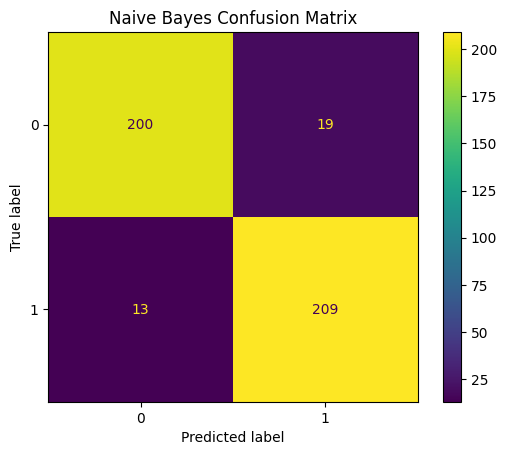

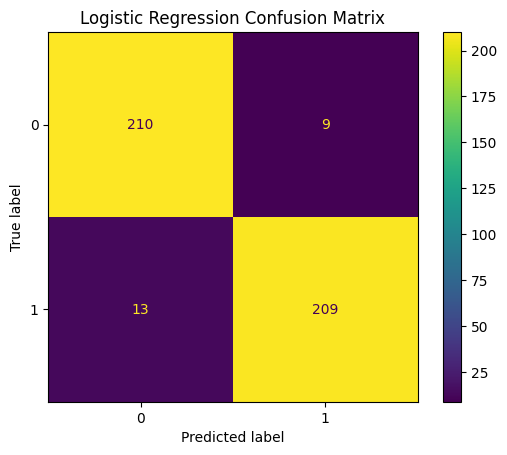

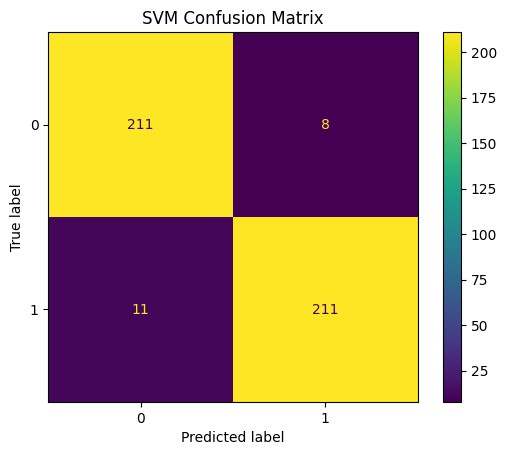

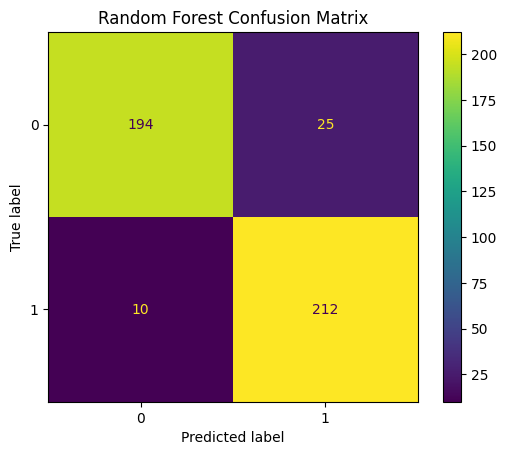

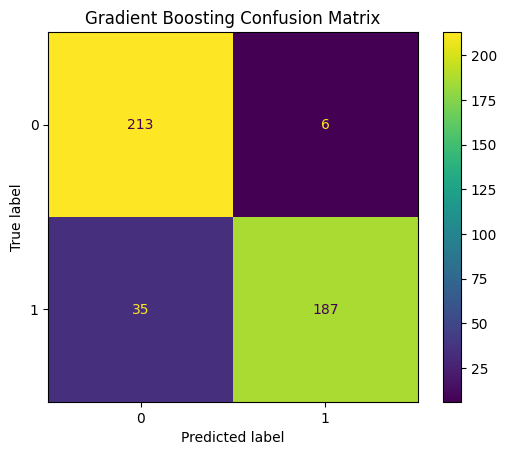

In [29]:
# ===============================
# 📊 ALL CONFUSION MATRICES
# ===============================
models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [30]:
print("\nNaive Bayes Report:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))
print("\nSVM Report:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))
print("\nLogistic Regression Report:",accuracy_score(y_test,lr_pred))
print(classification_report(y_test, lr_pred))
print("Random Forest", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))   # ✅ FIX

print("Gradient Boosting", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))   # ✅ FIX


Naive Bayes Report: 0.927437641723356
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       219
           1       0.92      0.94      0.93       222

    accuracy                           0.93       441
   macro avg       0.93      0.93      0.93       441
weighted avg       0.93      0.93      0.93       441


SVM Report: 0.9569160997732427
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       219
           1       0.96      0.95      0.96       222

    accuracy                           0.96       441
   macro avg       0.96      0.96      0.96       441
weighted avg       0.96      0.96      0.96       441


Logistic Regression Report: 0.9501133786848073
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       219
           1       0.96      0.94      0.95       222

    accuracy                           0.95       441
   macro 

In [31]:
# VALIDATION PERFORMANCE (REAL CHECK)
print("\n===== VALIDATION RESULTS =====")

# Naive Bayes (TEXT ONLY)
nb_pred = nb_model.predict(X_val_vec)
print("NB Validation Accuracy:", accuracy_score(y_val, nb_pred))

# Other models (TEXT + SOURCE)
models_val = {
    "LR": lr_model,
    "SVM": svm_model,
    "RF": rf_model,
    "GB": gb_model
}

for name, model in models_val.items():
    pred = model.predict(X_val_final)
    acc = accuracy_score(y_val, pred)
    print(f"{name} Validation Accuracy:", acc)


===== VALIDATION RESULTS =====
NB Validation Accuracy: 0.9386363636363636
LR Validation Accuracy: 0.9590909090909091
SVM Validation Accuracy: 0.9636363636363636
RF Validation Accuracy: 0.9113636363636364
GB Validation Accuracy: 0.8954545454545455


In [32]:
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

# Check duplicates
duplicates = data.duplicated(subset=['processed_text']).sum()
print("Duplicate texts:", duplicates)

Train size: 2053
Test size: 441
Duplicate texts: 0


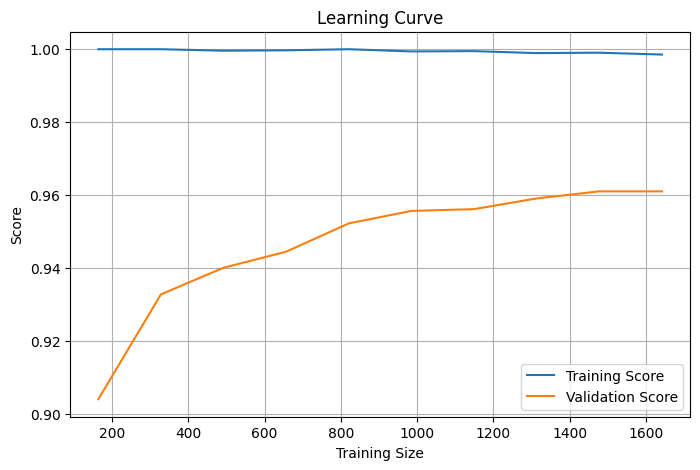

In [33]:
###  LEARNING CURVE
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, test_scores = learning_curve(
    svm_model,              # ✅ FIXED
    X_train_final,          # ✅ IMPORTANT FIX
    y_train,
    train_sizes=train_sizes,
    cv=5,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes_abs, train_mean, label="Training Score")
plt.plot(train_sizes_abs, test_mean, label="Validation Score")

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

In [34]:
# ===============================
# 🔄 RECOMPUTE TEST PREDICTIONS (CLEAN)
# ===============================

# NB → text only
nb_pred = nb_model.predict(X_test_vec)

# others → text + source
lr_pred  = lr_model.predict(X_test_final)
svm_pred = svm_model.predict(X_test_final)
rf_pred  = rf_model.predict(X_test_final)
gb_pred  = gb_model.predict(X_test_final)

print(len(y_test), len(nb_pred), len(svm_pred))

441 441 441


In [35]:
# ===============================
# 📊 MODEL COMPARISON TABLE (FIXED)
# ===============================

model_names = ["Naive Bayes", "Logistic Regression", "SVM", "Random Forest", "Gradient Boosting"]

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, gb_pred)
]

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

print(comparison_df)

                 Model  Accuracy
0          Naive Bayes  0.927438
1  Logistic Regression  0.950113
2                  SVM  0.956916
3        Random Forest  0.920635
4    Gradient Boosting  0.907029


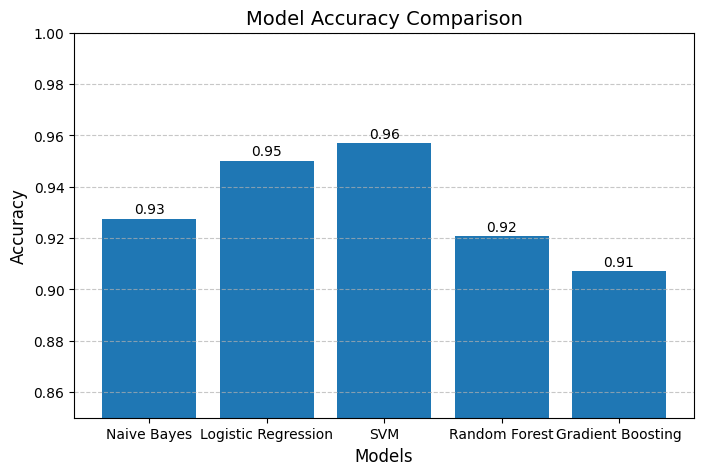

In [36]:
# ===============================
# 📈 PROFESSIONAL MODEL COMPARISON GRAPH
# ===============================
plt.figure(figsize=(8, 5))

bars = plt.bar(model_names, accuracies)

plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.2f}", ha='center', fontsize=10)

plt.ylim(0.85, 1.0)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

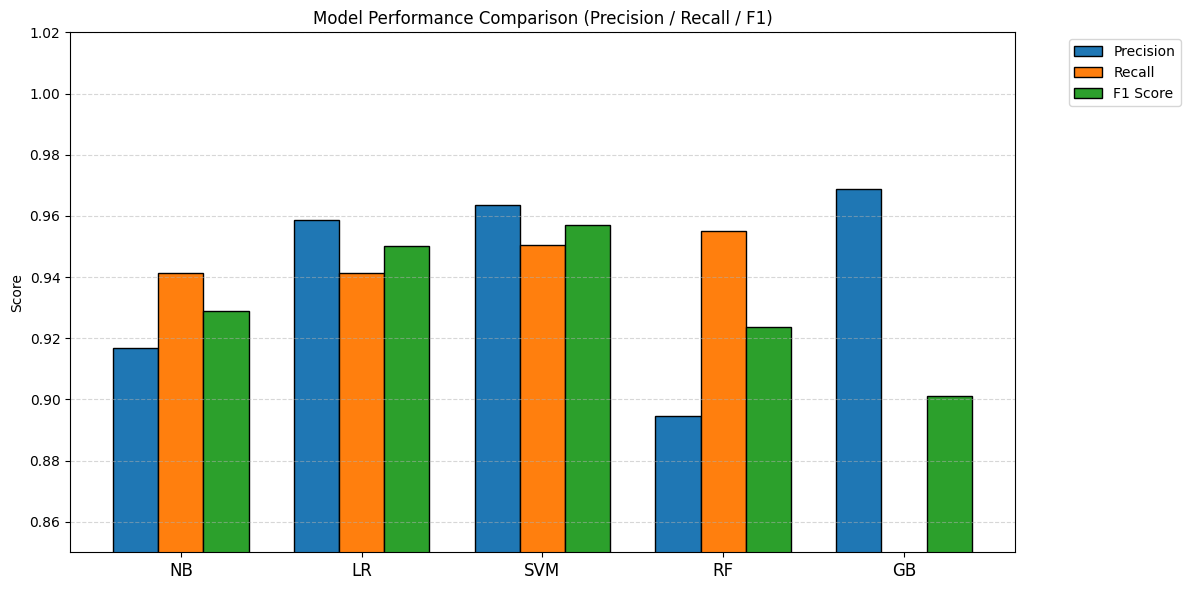

In [37]:
# ===============================
# 📊 PRECISION / RECALL / F1 GRAPH (VISIBILITY FIXED)
# ===============================

from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

model_names = ["NB", "LR", "SVM", "RF", "GB"]

precision = [
    precision_score(y_test, nb_pred),
    precision_score(y_test, lr_pred),
    precision_score(y_test, svm_pred),
    precision_score(y_test, rf_pred),
    precision_score(y_test, gb_pred)
]

recall = [
    recall_score(y_test, nb_pred),
    recall_score(y_test, lr_pred),
    recall_score(y_test, svm_pred),
    recall_score(y_test, rf_pred),
    recall_score(y_test, gb_pred)
]

f1 = [
    f1_score(y_test, nb_pred),
    f1_score(y_test, lr_pred),
    f1_score(y_test, svm_pred),
    f1_score(y_test, rf_pred),
    f1_score(y_test, gb_pred)
]

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(12,6))

# 🔥 add edgecolor so bars don’t visually merge
plt.bar(x - width, precision, width=width, label="Precision", edgecolor='black')
plt.bar(x, recall, width=width, label="Recall", edgecolor='black')
plt.bar(x + width, f1, width=width, label="F1 Score", edgecolor='black')

plt.xticks(x, model_names, fontsize=12)

plt.title("Model Performance Comparison (Precision / Recall / F1)")
plt.ylabel("Score")

# give enough headroom
plt.ylim(0.85, 1.02)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# legend outside so it never overlaps GB
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1))

plt.tight_layout()

plt.show()

In [38]:
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

Best Model: SVM
Best Accuracy: 0.9569160997732427


In [39]:
scores = cross_val_score(svm_model, X_train_final, y_train, cv=5)
print("Cross-validation mean:", scores.mean())

Cross-validation mean: 0.9605495222835441


In [40]:
##  PREDICTION FUNCTION

def predict_news(text, source):

    cleaned = normalize_tigrigna(clean_text(text))
    tokens = clean_tokens(tokenize(cleaned))
    processed = " ".join(tokens)

    text_vec = vectorizer.transform([processed])

    # FIX: must be list of list
    source_vec = hasher.transform([[source]]) * 0.2

    final_input = hstack([text_vec, source_vec])

    pred = svm_model.predict(final_input)

    return "REAL" if pred[0] == 1 else "FAKE"

In [56]:
def predict_with_confidence(text):

    cleaned = normalize_tigrigna(clean_text(text))
    tokens = clean_tokens(tokenize(cleaned))
    processed = " ".join(tokens)

    text_vec = vectorizer.transform([processed])

    decision = svm_model.decision_function(text_vec)[0]
    prediction = svm_model.predict(text_vec)[0]

    return prediction, decision

In [57]:
##  RANDOM TEST LOOP

for i in range(20):
    idx = random.randint(0, len(data)-1)

    text = data['processed_text'].iloc[idx]
    actual = data['label'].iloc[idx]

    source = data['source'].iloc[idx]
    prediction = predict_news(text, source)

    print("\n📝 TEXT:", text[:2000], "...")
    print("✅ ACTUAL:", "REAL" if actual == 1 else "FAKE")
    print("🤖 PREDICTED:", prediction)


📝 TEXT: ኣርእስቲ መምህር ነቶም ንሃጋራዊ መዝሙር ብምኽባር ኢዶም ልቦም ዠንባሩ ወዲ ዓመት ተምሃሮ ኣብነት ብምግባር ኣዋሪዳቶም ዜና ኣትላንታ ዝርከብ ኦርስ ኤለመንተሪ ስኩል ዠጋጠመ ዠካታዒ ፍጻመ የዠንትው ጄሰን ኒውባሪ ዝተባህለ ወዲ ዓመት ተምሃሮን ሀዳ ጻውቱን ግዜ ቃል ኪዳን እሙንነት ኢዶም ልቦም ብምንባር ክብሮም ክጋልጹ ከለዉ መምህሮምን ተምሃሮን ከቢድ ነቐፌታን ላግጽን ከም ዝባጽሖም ይጋልጹ ...
✅ ACTUAL: FAKE
🤖 PREDICTED: FAKE

📝 TEXT: ኣዳላዊ መዳብ ሲኤንኤን ዶን ለሞን ምስቶም ነጋራት ስለዠይሰማምዑ ጥራይ ሀሶት ዜና ዝብሉ ዓቃባውያን ኣጋጢምዎ ነታ ነጥቢ ዓው ኢሉን ብንጹርን ረኺብዋ ሀዳ ጋሻ መርባብ ሀሶት ዜናታት ይዳፍእ ኢሉ ክማጎት ምፍቃድ ሃንዳባት ንሀዳ ክፋል ቆረጾ ፓሪስ ዳናርድ ዝተባህለት ተንታኒ ፖለቲካን ወሃቢ ርእይቶን መወዳእታ ርእይቶኡ ክህብ ዕድል ረካባ ነጋራት ምሉእ ብምሉእ ባቡር ወጺኦም ዳናርድ ዝዛረቡሉ ዝነባሩ ኣርእስቲ ብምሉኡ ሀሶት ዜና ምዃኑ ኣዊጁ ፕረዚዳንት ዝኾነ ሕጊ ኣይጥሕስን ዋላ ሀንቲ ኣይጋብርን ይብል ዳናርድግን ለሞን ኣይነባሮን ኣዳላዊ መዳብ ሲኤንኤን ንዴናርድ ቆሪጹ ንዕኡን ነቶም ጋዛ ዝነባሩ ተዓዠብትን ብዛዕባ ሀሶት ዜና ዝብል ቃል ብሀቂ ማለት ምዃኑ ከስተምህሮ ወሲኑ ሀሶት ዜና ማለት ንሀዳ ሰብ ኮነ ኢልካ ከተዳናግር ዛንታ ኣውጺእካ ጌጋ ምዃኑ እትፈልጥ ኢሉ ንጋብሮ ዠለና ዛንታ ንማንም ኮነ ኢልና ንምትላል ኣይኮነን ብዛዕባ ሀዳ ፕረዚዳንት ውሑስ ንምግባር ዝወጽእ ወጻኢታት ጥራይ ኢና ንዛረብ ዠለና ክብል ኣስዒቡ ባጃኹም ባታ ዕሽነት ዝዛረባ ነጥቢ ሀሶት ዜና ምዃኑ ዳው ኣቢልዋ ኣብዚ መርባብ ሀባሬታ ዝቐርብ ዜናታት ክትሳተፉ እንተዠይዳሊኹም ሽዑ ኣይትመጹን ተሳተፉን ምስኦም ስለዠይትሰማማዕ ሀሶት ኣይት

In [43]:
# ===============================
# ❌ SHOW WRONG PREDICTIONS (FIXED)
# ===============================

wrong = []

for i in range(len(X_test_text)):
    vec = X_test_final[i]
    pred = svm_model.predict(vec)
    actual = y_test.iloc[i]

    if pred != actual:
        wrong.append(i)

print("Total wrong predictions:", len(wrong))

for i in wrong[:5]:
    print("\n📝 TEXT:", X_test_text.iloc[i][:3000])
    print("❌ ACTUAL:", y_test.iloc[i])
    print("🤖 PREDICTED:", svm_model.predict(X_test_final[i])[0])

Total wrong predictions: 19

📝 TEXT: ዋሺንግተን ሮይተርስ ጄምስ ኮሚ ሃዋርድ ዩኒቨርሲቲ ብተቓውሞ ተቀቢሎምዎ ዋሺንግተን ሮይተርስ ቀዳም ዳይሬክተር ጄምስ ኮሚ ስራሕ ምስጓጉ ንፈለማ ግዜ ዝሃቦ ህዝባዊ መዳረ ሃዋርድ ዩኒቨርሲቲ ብተመሃሮ ጻውዒት ተቓውሞን ጫውጫውታን ጋጢምዎ ተመሃሮ ኮሚ መዳረኡ ክጅምር ከሎ ዝብል ሰብኣዊ መሰላት መዝሙር ብምድማጽ ክቃወምዎ ፀኒሖም ተቓወምቲ ልዕሊ ፀለምቲ ተጣባቕቲ መሰላት ዝኽተሎ ኣጋባብ ብምቅዋም ጄምስ ኮሚ ውጻእ ዓርክና ኣይኮንካን ክብሉ ጭርሖታት ኣስሚዖም ኮሚ ብወጋኑ ነቲ ተቓውሞ ዕድል ብምሃብ ኣብቲ ሀቂ ዓለም ሰባት ሰሚዖም ክእመኑ ኣዝዩ ከቢድ ብምባል ምላሽ ሂቡ ጄምስ ኮሚ ፕረዚዳንት ትራምፕ ልዕሊ ሩስያ ዝግባር ዝነባረ ምርመራ ንምዕንቃፍ ስራሕ ኣሰጉኒ ክብል ምኽሳሱ ይዝከር
❌ ACTUAL: 1
🤖 PREDICTED: 0

📝 TEXT: ጕጅለ መርመራ ሙለር ሀዳ ላዕለዋይ መርማሪ ተኣልዩ ብዛዕባ ኢድ ኣእታውነት ሩስያ ዝምርምር ዠሎ ሮባርት ሙለር ፒተር ስትሮክ ዝተባህለ ላዕለዋይ መርማሪ ጕጅለኡ ኣልይዎ ምኽንያት ስትሮክ ሀንቲ መሳርሕቱ ዝተለዋወጦ ጽሑፍ መልእኽትታት ንትራምፕ ዝነቅፍን ንሂላሪ ክሊንተን ዝድግፍን ርእይቶታት ብምግላጹ ሳዕቤን ፍጻመ ዳጋፍቲ ትራምፕ ነቲ መርመራ ሙለር ንምንቃፍን ተኣማኒነቱ ንምጉዳልን ከም መርትዖ ይጥቀሙሉ ኣለዉ ስትሮክ ኣብቲ ሂላሪ ክሊንተን ኢሜይል መርመራ ዓቢ ተራ ዝነባሮ ሰብ ምላሽ መርመራ ቤት ጽሕፈት ሙለር ነቲ ወረ ሰምኣ ብኡንብኡ ንስትሮክ ካብቲ መርመራ ከም ዠርሀቖ ኣረጋጊጹ
❌ ACTUAL: 1
🤖 PREDICTED: 0

📝 TEXT: ፖስትካርድ ግብሪ ሕልሚዶ ወይስ ሀቂ ኣፈጉባኤ ፖል ራያንን ፕረዚዳንት ዶናልድ ትራምፕን ሀድሽ ግብሪ ሕጊ ንኣመሪካውያን ግብሮም ሀንቲ ንእሽቶ ፖስትካርድ ዝመ

In [44]:
##   CROSS VALIDATION

scores = cross_val_score(svm_model, X_train_vec, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Average:", scores.mean())

Cross-validation scores: [0.95863747 0.96593674 0.94890511 0.96341463 0.97560976]
Average: 0.9625007417957392


In [45]:
# =========================================
# 🚀 FINAL PIPELINE TRAINING (LOGISTIC REGRESSION VERSION)
# =========================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib
import os

# USE PROCESSED TEXT
X_clean = data['processed_text']
y_clean = data['label']

pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1,2),
        min_df=3,
        max_df=0.7,
        sublinear_tf=True
    )),
    
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight='balanced'
    ))
])

# TRAIN
pipeline.fit(X_clean, y_clean)

# SAVE MODEL
BASE_DIR = os.path.abspath("..")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

pipeline_path = os.path.join(MODEL_DIR, "pipeline.pkl")

joblib.dump(pipeline, pipeline_path)

print("✅ Saved at:", pipeline_path)

✅ Saved at: C:\Dev\Final_Project\models\pipeline.pkl


In [46]:
p = joblib.load("../models/pipeline.pkl")  # from notebook

print("Vectorizer fitted:", hasattr(p.named_steps["vectorizer"], "idf_"))
print("Test prediction:", p.predict(["እዚ ዜና ትክክል እዩ"]))

Vectorizer fitted: True
Test prediction: [0]


In [47]:
import sklearn
import joblib
import numpy
import pandas
import scipy
import matplotlib
import streamlit

print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("streamlit:", streamlit.__version__)

sklearn: 1.4.2
joblib: 1.3.2
numpy: 1.26.4
pandas: 2.2.2
scipy: 1.11.4
matplotlib: 3.8.4
streamlit: 1.32.0


In [48]:
import sklearn
print(sklearn.__version__)

1.4.2


In [49]:
import sys
print(sys.executable)

C:\Dev\Final_Project\.venv\Scripts\python.exe


In [50]:
import os

print(os.path.exists(pipeline_path))

True


In [51]:
import os

print("File size:", os.path.getsize(pipeline_path))

File size: 8277313


In [52]:
print(pipeline.named_steps)

{'vectorizer': TfidfVectorizer(max_df=0.7, max_features=10000, min_df=3, ngram_range=(1, 2),
                sublinear_tf=True), 'model': LogisticRegression(class_weight='balanced', max_iter=5000)}


In [53]:
print(type(pipeline.named_steps["model"]))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
